# Fraud Detection Pipeline - Full Implementation
## Mining Reviewer Rings: A Forensic Pipeline for Coordinated Fraud

This notebook implements the complete 5-stage fraud detection pipeline:
1. **Phase 1**: Text Forensics via Shingling and LSH
2. **Phase 2**: Frequent Itemset Mining for Reviewer Rings
3. **Phase 3**: Similarity Metrics and Feature Engineering
4. **Phase 4**: Clustering Campaign Archetypes with DBSCAN
5. **Phase 5**: Anomaly Detection on DBSCAN Noise with One-Class SVM

## Setup and Imports

In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import time
from tqdm import tqdm
import pickle

# Text processing and LSH
from datasketch import MinHash, MinHashLSH

# Frequent itemset mining
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Scikit-learn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.svm import OneClassSVM

# Set random seed
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# Cache directory for heavy computations
cache_dir = Path('cache')
cache_dir.mkdir(exist_ok=True)

print(f"Cache directory: {cache_dir.absolute()}")

All libraries imported successfully!
Cache directory: c:\Users\mbark\Desktop\Data Mining Project\cache


## Load Processed Data

In [2]:
print("="*70)
print("Loading Amazon Appliances Data")
print("="*70)

# Load Amazon Appliances reviews
reviews_df = pl.read_ndjson('Appliances/Appliances.jsonl')

print(f"Raw reviews loaded: {len(reviews_df):,}")
print(f"Columns: {reviews_df.columns}")

# Process and rename columns for pipeline consistency
reviews_df = reviews_df.with_columns([
    # Create unique review_id
    pl.concat_str([pl.col('user_id'), pl.lit('_'), pl.col('asin')]).alias('review_id'),
    # Rename for consistency
    pl.col('rating').alias('stars'),
    pl.col('parent_asin').alias('business_id'),
    # Text features
    pl.col('text').fill_null('').str.len_chars().alias('text_length'),
    pl.col('text').fill_null('').str.split(' ').list.len().alias('word_count'),
    # Convert timestamp
    pl.from_epoch(pl.col('timestamp'), time_unit='ms').alias('datetime'),
    # Verified purchase (already exists)
    pl.col('verified_purchase').cast(pl.Int8)
])

# Fill null text
reviews_df = reviews_df.with_columns([
    pl.col('text').fill_null('')
])

reviews_pd = reviews_df.to_pandas()

# No ground truth labels for Amazon data
ground_truth_labels = None

print(f"\n" + "="*70)
print("Amazon Appliances Dataset Loaded")
print("="*70)
print(f"Total reviews: {len(reviews_df):,}")
print(f"Unique users: {reviews_df['user_id'].n_unique():,}")
print(f"Unique products: {reviews_df['business_id'].n_unique():,}")
print(f"Verified purchases: {reviews_df['verified_purchase'].mean()*100:.1f}%")
print(f"Average rating: {reviews_df['stars'].mean():.2f}")
print("="*70)

print(f"\nSample review:")
sample_text = reviews_pd['text'].iloc[0]
print(sample_text[:200] if len(sample_text) > 0 else "(empty)")

Loading Amazon Appliances Data
Raw reviews loaded: 2,128,605
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Amazon Appliances Dataset Loaded
Total reviews: 2,128,605
Unique users: 1,755,732
Unique products: 94,319
Verified purchases: 95.8%
Average rating: 4.22

Sample review:
work great. use a new one every month


---
# PHASE 1: Text Forensics via Shingling and LSH
---

## 1.1 Shingling Implementation

In [3]:
def create_shingles(text, k=3):
    """Generate k-word shingles from text."""
    if not isinstance(text, str) or len(text) == 0:
        return set(['empty'])
    
    words = text.lower().split()
    if len(words) < k:
        return set([' '.join(words)]) if words else set(['empty'])
    
    shingles = set()
    for i in range(len(words) - k + 1):
        shingle = ' '.join(words[i:i+k])
        shingles.add(shingle)
    return shingles

# Test shingling
test_text = "this product is amazing and I love it"
test_shingles = create_shingles(test_text, k=3)
print("Example shingles (k=3):")
for shingle in sorted(test_shingles)[:5]:
    print(f"  '{shingle}'")

Example shingles (k=3):
  'amazing and i'
  'and i love'
  'i love it'
  'is amazing and'
  'product is amazing'


## 1.2 MinHash Signature Generation

In [4]:
def create_minhash(shingles, num_perm=128):
    """Create MinHash signature from shingles."""
    m = MinHash(num_perm=num_perm)
    for shingle in shingles:
        m.update(shingle.encode('utf8'))
    return m

print("MinHash signature function ready!")
print(f"Using 128 permutations for MinHash signatures")

MinHash signature function ready!
Using 128 permutations for MinHash signatures


## 1.3 Build LSH Index

In [5]:
print("Building LSH index...")

# LSH parameters
SHINGLE_SIZE = 3
NUM_PERM = 128
THRESHOLD = 0.7  # Jaccard similarity threshold

# Cache file path
lsh_cache_file = cache_dir / 'lsh_cache.pkl'

# Check if cache exists and is valid
if lsh_cache_file.exists():
    print("Loading LSH data from cache...")
    start_time = time.time()
    with open(lsh_cache_file, 'rb') as f:
        cache_data = pickle.load(f)
    
    lsh = cache_data['lsh']
    minhash_dict = cache_data['minhash_dict']
    shingle_dict = cache_data['shingle_dict']
    
    lsh_build_time = time.time() - start_time
    print(f"Loaded from cache in {lsh_build_time:.2f} seconds")
    print(f"Reviews in cache: {len(minhash_dict):,}")
else:
    print("No cache found. Building LSH index from scratch...")
    print("This may take several minutes...\n")
    
    # Create LSH index
    lsh = MinHashLSH(threshold=THRESHOLD, num_perm=NUM_PERM)
    
    # Store signatures and shingles
    minhash_dict = {}
    shingle_dict = {}
    
    start_time = time.time()
    
    print(f"Processing {len(reviews_pd)} reviews...")
    for idx, row in tqdm(reviews_pd.iterrows(), total=len(reviews_pd), desc="Building LSH"):
        review_id = row['review_id']
        text = row['text'] if pd.notna(row['text']) else ''
        
        shingles = create_shingles(text, k=SHINGLE_SIZE)
        minhash = create_minhash(shingles, num_perm=NUM_PERM)
        
        shingle_dict[review_id] = shingles
        minhash_dict[review_id] = minhash
        
        try:
            lsh.insert(review_id, minhash)
        except ValueError:
            pass  # Skip duplicate keys
    
    lsh_build_time = time.time() - start_time
    print(f"\nLSH index built in {lsh_build_time:.2f} seconds")
    
    # Save to cache
    print("Saving to cache...")
    with open(lsh_cache_file, 'wb') as f:
        pickle.dump({
            'lsh': lsh,
            'minhash_dict': minhash_dict,
            'shingle_dict': shingle_dict
        }, f)
    print(f"Cache saved to {lsh_cache_file}")

print(f"Average time per review: {lsh_build_time/len(reviews_pd)*1000:.2f} ms")

Building LSH index...
Loading LSH data from cache...
Loaded from cache in 54.21 seconds
Reviews in cache: 314,737
Average time per review: 0.03 ms


## 1.4 Query LSH for Near-Duplicates

In [6]:
print("Finding near-duplicate pairs...\n")

def jaccard_similarity(set1, set2):
    """Calculate exact Jaccard similarity."""
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

# Cache file path
lsh_query_cache_file = cache_dir / 'lsh_query_results.pkl'

if lsh_query_cache_file.exists():
    print("Loading LSH query results from cache...")
    start_time = time.time()
    with open(lsh_query_cache_file, 'rb') as f:
        cache_data = pickle.load(f)
    
    near_duplicate_pairs = cache_data['near_duplicate_pairs']
    candidate_count = cache_data['candidate_count']
    lsh_query_time = time.time() - start_time
    
    print(f"Loaded from cache in {lsh_query_time:.2f} seconds")
else:
    print("No cache found. Running LSH queries...")
    
    near_duplicate_pairs = []
    candidate_count = 0
    seen_pairs = set()
    
    start_time = time.time()
    
    for review_id, minhash in tqdm(minhash_dict.items(), desc="Querying LSH"):
        candidates = lsh.query(minhash)
        candidate_count += len(candidates)
        
        for candidate_id in candidates:
            if candidate_id != review_id:
                pair_key = tuple(sorted([review_id, candidate_id]))
                if pair_key not in seen_pairs:
                    seen_pairs.add(pair_key)
                    jaccard = jaccard_similarity(shingle_dict[review_id], shingle_dict[candidate_id])
                    
                    if jaccard >= THRESHOLD:
                        near_duplicate_pairs.append({
                            'review_id_1': review_id,
                            'review_id_2': candidate_id,
                            'jaccard_similarity': jaccard
                        })
    
    lsh_query_time = time.time() - start_time
    
    # Save to cache
    print("Saving to cache...")
    with open(lsh_query_cache_file, 'wb') as f:
        pickle.dump({
            'near_duplicate_pairs': near_duplicate_pairs,
            'candidate_count': candidate_count
        }, f)
    print(f"Cache saved to {lsh_query_cache_file}")

print(f"\nLSH query completed in {lsh_query_time:.2f} seconds")
print(f"Candidate pairs checked: {candidate_count:,}")
print(f"Near-duplicate pairs found (J >= {THRESHOLD}): {len(near_duplicate_pairs):,}")

Finding near-duplicate pairs...

Loading LSH query results from cache...
Loaded from cache in 5.67 seconds

LSH query completed in 5.67 seconds
Candidate pairs checked: 7,984,047
Near-duplicate pairs found (J >= 0.7): 3,819,581


---
# PHASE 2: Frequent Itemset Mining for Reviewer Rings
---

## 2.1 Build Transaction Database

In [9]:
print("Building transaction database for frequent itemset mining...\n")

# Use PRODUCT-level co-occurrence: each product = 1 transaction containing all its reviewers
transactions = reviews_df.group_by('business_id').agg(
    pl.col('user_id').unique().alias('reviewers')
).filter(
    pl.col('reviewers').list.len() >= 3  # Products with 3+ reviewers
)

print(f"Total transactions (products with 3+ reviewers): {len(transactions):,}")
print(f"Average reviewers per product: {transactions['reviewers'].list.len().mean():.1f}")
print(f"Max reviewers for a product: {transactions['reviewers'].list.len().max()}")

transaction_list = [list(item) for item in transactions['reviewers'].to_list()]
print(f"\nPrepared {len(transaction_list):,} transactions for FP-Growth")

Building transaction database for frequent itemset mining...

Total transactions (products with 3+ reviewers): 47,845
Average reviewers per product: 42.7
Max reviewers for a product: 11873

Prepared 47,845 transactions for FP-Growth


## 2.2 Run FP-Growth

In [10]:
print("Running FP-Growth...\n")

# Cache file path
fpgrowth_cache_file = cache_dir / 'fpgrowth_results.pkl'

if fpgrowth_cache_file.exists():
    print("Loading FP-Growth results from cache...")
    start_time = time.time()
    with open(fpgrowth_cache_file, 'rb') as f:
        cache_data = pickle.load(f)
    
    frequent_itemsets = cache_data['frequent_itemsets']
    reviewer_counts = cache_data['reviewer_counts']
    fpgrowth_time = time.time() - start_time
    
    print(f"Loaded from cache in {fpgrowth_time:.2f} seconds")
    print(f"Frequent itemsets: {len(frequent_itemsets):,}")
else:
    print("No cache found. Running FP-Growth from scratch...")
    
    # Count reviewer appearances across products
    reviewer_counts = Counter([user for basket in transaction_list for user in basket])
    
    print(f"Total unique reviewers: {len(reviewer_counts):,}")
    print(f"Reviewers in 2+ products: {sum(1 for c in reviewer_counts.values() if c >= 2):,}")
    print(f"Reviewers in 3+ products: {sum(1 for c in reviewer_counts.values() if c >= 3):,}")
    print(f"Reviewers in 5+ products: {sum(1 for c in reviewer_counts.values() if c >= 5):,}")
    
    # ============================================================
    # OPTIMIZATION: Only keep reviewers in 3+ products (more selective)
    # This drastically reduces the transaction matrix size
    # ============================================================
    MIN_APPEARANCES = 3  # Increased from 2 to reduce matrix size
    active_reviewers = set([user for user, count in reviewer_counts.items() if count >= MIN_APPEARANCES])
    print(f"\nActive reviewers ({MIN_APPEARANCES}+ products): {len(active_reviewers):,}")
    
    # Cap at 2000 most frequent reviewers to prevent memory issues
    MAX_REVIEWERS = 2000
    if len(active_reviewers) > MAX_REVIEWERS:
        top_reviewers = [user for user, _ in reviewer_counts.most_common() if user in active_reviewers][:MAX_REVIEWERS]
        active_reviewers = set(top_reviewers)
        print(f"Capped to top {MAX_REVIEWERS} reviewers")
    
    # Filter transactions
    transaction_list_filtered = []
    for basket in transaction_list:
        filtered = [user for user in basket if user in active_reviewers]
        if len(filtered) >= 2:
            transaction_list_filtered.append(filtered)
    
    print(f"Transactions with 2+ active reviewers: {len(transaction_list_filtered):,}")
    
    # Skip if too few transactions or too many unique items
    num_unique = len(set([u for b in transaction_list_filtered for u in b]))
    print(f"Unique reviewers in filtered transactions: {num_unique:,}")
    
    if len(transaction_list_filtered) >= 10 and num_unique <= 3000:
        # Use higher min_support for speed (find pairs in at least 3 products)
        MIN_SUPPORT = max(3 / len(transaction_list_filtered), 0.005)
        print(f"\nUsing min_support = {MIN_SUPPORT:.6f}")
        
        # Encode and run FP-Growth
        print("Encoding transactions...")
        te = TransactionEncoder()
        te_ary = te.fit(transaction_list_filtered).transform(transaction_list_filtered, sparse=False)
        transaction_pd = pd.DataFrame(te_ary, columns=te.columns_)
        
        print(f"Transaction matrix: {transaction_pd.shape}")
        print(f"Memory: {transaction_pd.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
        
        print("Running FP-Growth...")
        start_time = time.time()
        frequent_itemsets = fpgrowth(transaction_pd, min_support=MIN_SUPPORT, use_colnames=True)
        fpgrowth_time = time.time() - start_time
        
        print(f"\nFP-Growth completed in {fpgrowth_time:.2f} seconds")
        print(f"Frequent itemsets found: {len(frequent_itemsets):,}")
        
        if len(frequent_itemsets) > 0:
            frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
            print(f"  Single items: {(frequent_itemsets['length'] == 1).sum():,}")
            print(f"  2-itemsets (pairs): {(frequent_itemsets['length'] == 2).sum():,}")
            print(f"  3+ itemsets: {(frequent_itemsets['length'] >= 3).sum():,}")
    else:
        if len(transaction_list_filtered) < 10:
            print("\nToo few transactions with overlapping reviewers")
        else:
            print(f"\nToo many unique reviewers ({num_unique:,}) - would be too slow")
        print("Skipping FP-Growth - pipeline will use other fraud signals")
        frequent_itemsets = pd.DataFrame(columns=['itemsets', 'support', 'length'])
        fpgrowth_time = 0
    
    # Save to cache
    print("Saving to cache...")
    with open(fpgrowth_cache_file, 'wb') as f:
        pickle.dump({
            'frequent_itemsets': frequent_itemsets,
            'reviewer_counts': reviewer_counts
        }, f)
    print(f"Cache saved to {fpgrowth_cache_file}")

Running FP-Growth...

Loading FP-Growth results from cache...
Loaded from cache in 0.27 seconds
Frequent itemsets: 626


## 2.3 Generate Association Rules

In [11]:
print("Generating association rules...\n")

high_lift_rules = None

if len(frequent_itemsets) > 0 and 'length' in frequent_itemsets.columns:
    has_pairs = (frequent_itemsets['length'] >= 2).any()
    
    if has_pairs:
        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
        print(f"Association rules generated: {len(rules):,}")
        
        if len(rules) > 0:
            MIN_LIFT = 1.5
            high_lift_rules = rules[rules['lift'] > MIN_LIFT].copy()
            print(f"Rules with lift > {MIN_LIFT}: {len(high_lift_rules):,}")
            
            if len(high_lift_rules) > 0:
                print(f"\nLift statistics:")
                print(f"  Mean: {high_lift_rules['lift'].mean():.2f}")
                print(f"  Max: {high_lift_rules['lift'].max():.2f}")
                print(f"\nTop 5 rules by lift:")
                print(high_lift_rules.nlargest(5, 'lift')[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
        else:
            print("No association rules generated")
    else:
        print("No 2+ member itemsets found")
else:
    print("No frequent itemsets found")
    print("Pipeline will rely on other signals (LSH, clustering, anomaly detection)")

Generating association rules...

Association rules generated: 28
Rules with lift > 1.5: 28

Lift statistics:
  Mean: 157.51
  Max: 197.33

Top 5 rules by lift:
                      antecedents                     consequents   support  \
0  (AHI3HCLGHA43YIYPLP4VO5VITPZA)  (AEPJVKZKKJA4T2UQQPWFPGV2MDFA)  0.005068   
1  (AEPJVKZKKJA4T2UQQPWFPGV2MDFA)  (AHI3HCLGHA43YIYPLP4VO5VITPZA)  0.005068   
2  (AEPW3OVXXVE4CU5A4EMWIGB6OB3A)  (AEDW6Z422OSZV7GNJ44EIBB6ORQQ)  0.005068   
3  (AEDW6Z422OSZV7GNJ44EIBB6ORQQ)  (AEPW3OVXXVE4CU5A4EMWIGB6OB3A)  0.005068   
4  (AEPW3OVXXVE4CU5A4EMWIGB6OB3A)  (AGHYCTZTCC5LGFVSRAYYENFJBR6A)  0.005068   

   confidence        lift  
0         1.0  197.333333  
1         1.0  197.333333  
2         1.0  197.333333  
3         1.0  197.333333  
4         1.0  197.333333  


## 2.4 Extract Reviewer Rings

In [12]:
print("Extracting reviewer rings...\n")

if len(frequent_itemsets) > 0 and 'length' in frequent_itemsets.columns:
    reviewer_rings = frequent_itemsets[frequent_itemsets['length'] >= 2].copy()
else:
    reviewer_rings = pd.DataFrame(columns=['itemsets', 'support', 'length'])

print(f"Reviewer rings (2+ members): {len(reviewer_rings):,}")

if len(reviewer_rings) > 0:
    ring_size_dist = reviewer_rings['length'].value_counts().sort_index()
    print(f"\nRing size distribution:")
    for size, count in ring_size_dist.items():
        print(f"  {size}-reviewer rings: {count:,}")

# Store for features
reviewer_rings_dict = {}
if len(reviewer_rings) > 0:
    for idx, row in reviewer_rings.iterrows():
        reviewers = frozenset(row['itemsets'])
        reviewer_rings_dict[reviewers] = row['support']

print(f"\nStored {len(reviewer_rings_dict)} rings for feature engineering")

Extracting reviewer rings...

Reviewer rings (2+ members): 10

Ring size distribution:
  2-reviewer rings: 8
  3-reviewer rings: 2

Stored 10 rings for feature engineering


## 2.5 Visualize Itemsets

C:\Users\mbark\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\mbark\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\mbark\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


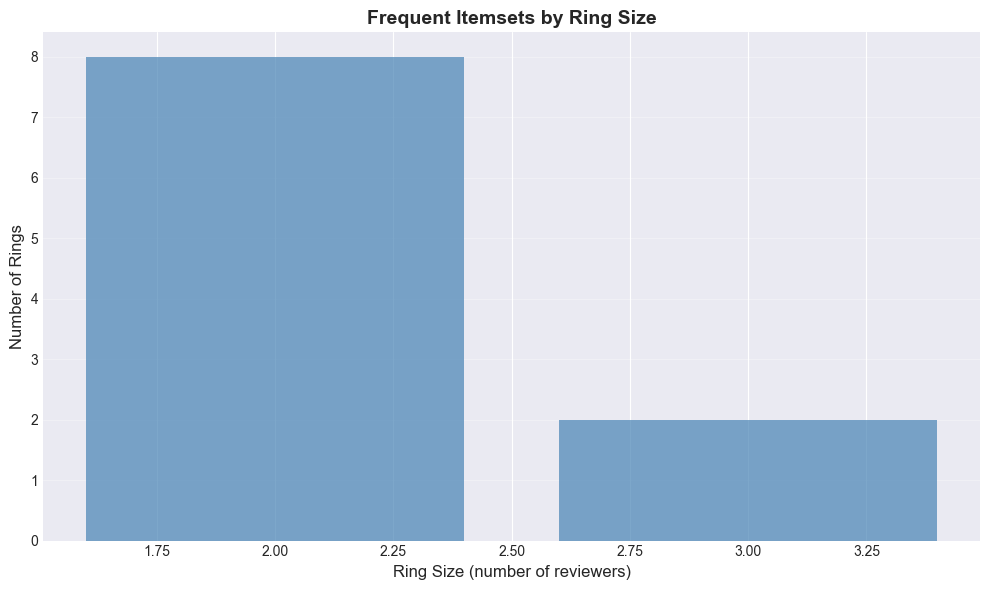

Figure 8 saved


In [13]:
# Figure 8: Itemsets visualization
if len(reviewer_rings) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ring_stats = reviewer_rings.groupby('length').agg({'support': ['count', 'mean']})
    ring_stats.columns = ['count', 'avg_support']
    ring_stats = ring_stats.reset_index()
    
    ax.bar(ring_stats['length'], ring_stats['count'], alpha=0.7, color='steelblue')
    ax.set_xlabel('Ring Size (number of reviewers)', fontsize=12)
    ax.set_ylabel('Number of Rings', fontsize=12)
    ax.set_title('Frequent Itemsets by Ring Size', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'fig8_itemsets.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Figure 8 saved")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.text(0.5, 0.5, 'No Frequent Itemsets Found\n\nReviewers do not frequently\nco-occur on the same products.\n\nThis is typical of legitimate reviews.',
            ha='center', va='center', fontsize=14, transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.axis('off')
    ax.set_title('FP-Growth Results', fontsize=14, fontweight='bold')
    plt.savefig(output_dir / 'fig8_itemsets.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Figure 8 saved (no itemsets found)")

---
# PHASE 3: Feature Engineering
---

## 3.1 Build Feature Vectors

In [14]:
print("Building feature vectors for each reviewer...\n")

# Cache file path
features_cache_file = cache_dir / 'features_cache.pkl'

if features_cache_file.exists():
    print("Loading features from cache...")
    start_time = time.time()
    with open(features_cache_file, 'rb') as f:
        features = pickle.load(f)
    
    feature_time = time.time() - start_time
    print(f"Loaded from cache in {feature_time:.2f} seconds")
    print(f"Features for {len(features):,} reviewers")
else:
    print("No cache found. Computing features from scratch...")
    start_time = time.time()
    
    # ============================================================
    # OPTIMIZED: Use vectorized groupby instead of row-by-row loop
    # ============================================================
    
    # Step 1: Pre-compute LSH hits lookup (O(n) instead of O(users * pairs))
    print("Building LSH hits lookup...")
    lsh_hits_counter = Counter()
    for pair in near_duplicate_pairs:
        lsh_hits_counter[pair['review_id_1']] += 1
        lsh_hits_counter[pair['review_id_2']] += 1
    
    # Map review_id -> user_id for LSH hits
    review_to_user = dict(zip(reviews_df['review_id'].to_list(), reviews_df['user_id'].to_list()))
    user_lsh_hits = Counter()
    for review_id, hits in lsh_hits_counter.items():
        if review_id in review_to_user:
            user_lsh_hits[review_to_user[review_id]] += hits
    
    # Step 2: Pre-compute itemset memberships lookup
    print("Building itemset memberships lookup...")
    user_itemset_memberships = Counter()
    for ring in reviewer_rings_dict.keys():
        for user_id in ring:
            user_itemset_memberships[user_id] += 1
    
    # Step 3: Pre-compute max lift lookup
    print("Building max lift lookup...")
    user_max_lift = {}
    if high_lift_rules is not None and len(high_lift_rules) > 0:
        for _, rule in high_lift_rules.iterrows():
            all_items = rule['antecedents'].union(rule['consequents'])
            for user_id in all_items:
                user_max_lift[user_id] = max(user_max_lift.get(user_id, 0), rule['lift'])
    
    # Step 4: Vectorized aggregation using Polars (MUCH faster than pandas loop)
    print("Computing aggregated features with Polars...")
    
    # Convert datetime if needed
    reviews_with_dt = reviews_df.with_columns(
        pl.col('datetime').cast(pl.Datetime).alias('dt')
    )
    
    # Compute all basic aggregations in one pass
    user_aggs = reviews_with_dt.group_by('user_id').agg([
        pl.len().alias('num_reviews'),
        pl.col('stars').mean().alias('avg_rating'),
        pl.col('stars').std().alias('rating_std'),
        pl.col('text_length').mean().alias('avg_text_length'),
        pl.col('word_count').mean().alias('avg_word_count'),
        pl.col('verified_purchase').mean().alias('verified_ratio'),
        # Collect dates for temporal calculation
        pl.col('dt').sort().alias('sorted_dates'),
        # Collect ratings for entropy calculation
        pl.col('stars').alias('all_ratings')
    ])
    
    print("Computing temporal and entropy features...")
    features = {}
    
    for row in tqdm(user_aggs.iter_rows(named=True), total=len(user_aggs), desc="Finalizing features"):
        user_id = row['user_id']
        num_reviews = row['num_reviews']
        
        # Temporal feature
        if num_reviews > 1 and row['sorted_dates'] is not None:
            dates = row['sorted_dates']
            if len(dates) > 1:
                time_diffs = [(dates[i] - dates[i-1]).total_seconds() / 86400 
                              for i in range(1, len(dates))]
                avg_days_between = np.mean(time_diffs) if time_diffs else 0
            else:
                avg_days_between = 0
        else:
            avg_days_between = 0
        
        # Rating entropy
        ratings = row['all_ratings']
        if ratings and len(ratings) > 0:
            rating_counts = Counter(ratings)
            total = sum(rating_counts.values())
            probs = np.array([c / total for c in rating_counts.values()])
            rating_entropy = -np.sum(probs * np.log2(probs + 1e-10))
        else:
            rating_entropy = 0
        
        # Get pre-computed lookup values (O(1) instead of O(n))
        lsh_hits = user_lsh_hits.get(user_id, 0)
        itemset_memberships = user_itemset_memberships.get(user_id, 0)
        max_lift = user_max_lift.get(user_id, 0)
        
        rating_std = row['rating_std']
        
        features[user_id] = {
            'num_reviews': num_reviews,
            'avg_rating': row['avg_rating'],
            'rating_std': rating_std if rating_std is not None and not np.isnan(rating_std) else 0,
            'avg_text_length': row['avg_text_length'],
            'avg_word_count': row['avg_word_count'],
            'verified_ratio': row['verified_ratio'],
            'avg_days_between': avg_days_between,
            'rating_entropy': rating_entropy,
            'lsh_hits': lsh_hits,
            'itemset_memberships': itemset_memberships,
            'max_lift': max_lift
        }
    
    feature_time = time.time() - start_time
    print(f"\nFeatures computed in {feature_time:.2f} seconds")
    
    # Save to cache
    print("Saving to cache...")
    with open(features_cache_file, 'wb') as f:
        pickle.dump(features, f)
    print(f"Cache saved to {features_cache_file}")

print(f"\nFeatures computed for {len(features):,} reviewers")
print(f"Feature dimensions: {len(list(features.values())[0])}")

Building feature vectors for each reviewer...

Loading features from cache...
Loaded from cache in 1.11 seconds
Features for 303,472 reviewers

Features computed for 303,472 reviewers
Feature dimensions: 11


In [15]:
# Convert to DataFrame
features_df = pl.DataFrame([{'user_id': uid, **feat} for uid, feat in features.items()])
print("Feature matrix:")
print(features_df.describe())

Feature matrix:
shape: (9, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ user_id   ┆ num_revie ┆ avg_ratin ┆ … ┆ rating_en ┆ lsh_hits  ┆ itemset_m ┆ max_lift │
│ ---       ┆ ---       ┆ ws        ┆ g         ┆   ┆ tropy     ┆ ---       ┆ embership ┆ ---      │
│ str       ┆ str       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ f64       ┆ s         ┆ f64      │
│           ┆           ┆ f64       ┆ f64       ┆   ┆ f64       ┆           ┆ ---       ┆          │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 303472    ┆ 303472.0  ┆ 303472.0  ┆ … ┆ 303472.0  ┆ 303472.0  ┆ 303472.0  ┆ 303472.0 │
│ null_coun ┆ 0         ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆       

## 3.2 PCA Dimensionality Reduction

In [16]:
print("Applying PCA...\n")

feature_cols = [col for col in features_df.columns if col != 'user_id']
X = features_df.select(feature_cols).to_numpy()
user_ids = features_df['user_id'].to_numpy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"PCA dimensions: {X_pca.shape[1]}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Applying PCA...

Original dimensions: 11
PCA dimensions: 8
Variance retained: 98.3%


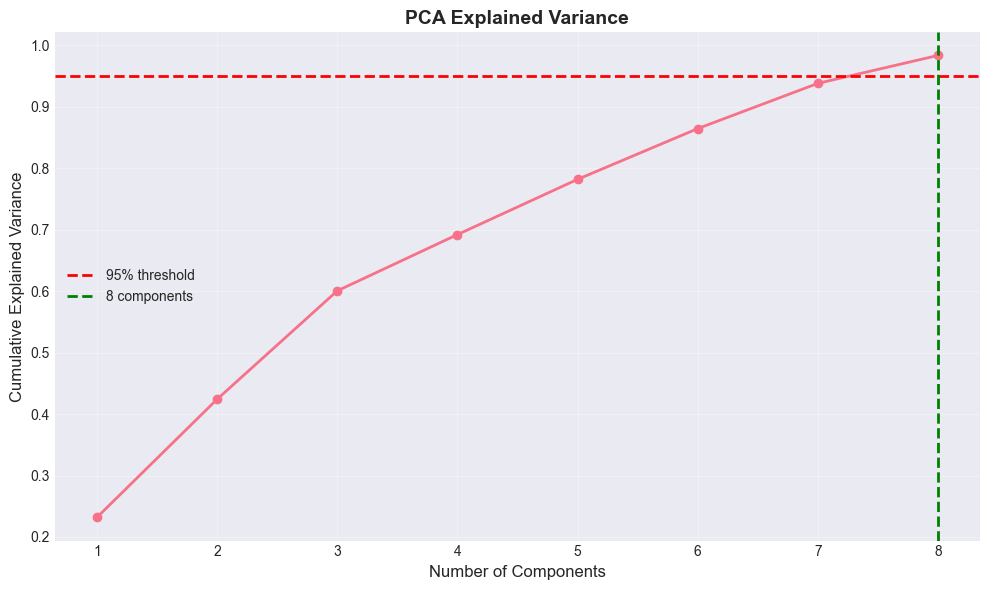

Figure 4 saved


In [17]:
# Figure 4: PCA explained variance
fig, ax = plt.subplots(figsize=(10, 6))

cumsum = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, len(cumsum)+1), cumsum, marker='o', linewidth=2)
ax.axhline(0.95, color='red', linestyle='--', linewidth=2, label='95% threshold')
ax.axvline(pca.n_components_, color='green', linestyle='--', linewidth=2, label=f'{pca.n_components_} components')

ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax.set_title('PCA Explained Variance', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'fig4_pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4 saved")

---
# PHASE 4: Clustering
---

## 4.3 DBSCAN

In [18]:
print("Running DBSCAN...\n")

EPS = 0.5
MIN_SAMPLES = 5

# DBSCAN is O(n²) memory - sample for large datasets
DBSCAN_MAX_SAMPLES = 50000

if len(X_pca) > DBSCAN_MAX_SAMPLES:
    print(f"Dataset too large ({len(X_pca):,}), sampling {DBSCAN_MAX_SAMPLES:,} points for DBSCAN...")
    
    # Sample indices
    dbscan_sample_idx = np.random.choice(len(X_pca), DBSCAN_MAX_SAMPLES, replace=False)
    X_dbscan = X_pca[dbscan_sample_idx]
    
    # Fit on sample
    dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
    dbscan_sample_labels = dbscan.fit_predict(X_dbscan)
    
    # Assign full dataset: use nearest neighbor from sample
    print("Assigning labels to full dataset via nearest neighbors...")
    from sklearn.neighbors import NearestNeighbors
    
    # For each point not in sample, find nearest sampled point and copy its label
    # Points far from any cluster get noise label
    dbscan_labels = np.full(len(X_pca), -1)  # Default to noise
    dbscan_labels[dbscan_sample_idx] = dbscan_sample_labels
    
    # Find non-sampled points
    all_idx = set(range(len(X_pca)))
    sampled_set = set(dbscan_sample_idx)
    non_sampled_idx = np.array(list(all_idx - sampled_set))
    
    if len(non_sampled_idx) > 0:
        # Fit NN on sampled cluster centers (non-noise points)
        clustered_mask = dbscan_sample_labels != -1
        if clustered_mask.sum() > 0:
            nn = NearestNeighbors(n_neighbors=1)
            nn.fit(X_dbscan[clustered_mask])
            
            # Query non-sampled points
            distances, indices = nn.kneighbors(X_pca[non_sampled_idx])
            
            # Assign label if close enough (within 2*EPS)
            close_enough = distances.flatten() < (2 * EPS)
            clustered_sample_labels = dbscan_sample_labels[clustered_mask]
            
            for i, (idx, is_close) in enumerate(zip(non_sampled_idx, close_enough)):
                if is_close:
                    dbscan_labels[idx] = clustered_sample_labels[indices[i, 0]]
    
    print(f"Labels assigned to all {len(X_pca):,} points")
else:
    dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
    dbscan_labels = dbscan.fit_predict(X_pca)

# Silhouette on sample (exclude noise)
non_noise = dbscan_labels != -1
non_noise_count = non_noise.sum()

if non_noise_count > 1 and len(np.unique(dbscan_labels[non_noise])) > 1:
    SILHOUETTE_SAMPLE = 10000
    if non_noise_count > SILHOUETTE_SAMPLE:
        print(f"Computing silhouette on {SILHOUETTE_SAMPLE:,} sample...")
        non_noise_idx = np.where(non_noise)[0]
        sample_idx = np.random.choice(non_noise_idx, SILHOUETTE_SAMPLE, replace=False)
        dbscan_silhouette = silhouette_score(X_pca[sample_idx], dbscan_labels[sample_idx])
    else:
        dbscan_silhouette = silhouette_score(X_pca[non_noise], dbscan_labels[non_noise])
else:
    dbscan_silhouette = 0.0

num_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
num_noise = (dbscan_labels == -1).sum()

print(f"\nDBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}):")
print(f"  Silhouette score: {dbscan_silhouette:.3f}")
print(f"  Clusters found: {num_clusters}")
print(f"  Noise points: {num_noise:,} ({num_noise/len(dbscan_labels)*100:.1f}%)")

Running DBSCAN...

Dataset too large (303,472), sampling 50,000 points for DBSCAN...
Assigning labels to full dataset via nearest neighbors...
Labels assigned to all 303,472 points
Computing silhouette on 10,000 sample...

DBSCAN (eps=0.5, min_samples=5):
  Silhouette score: 0.265
  Clusters found: 52
  Noise points: 4,066 (1.3%)


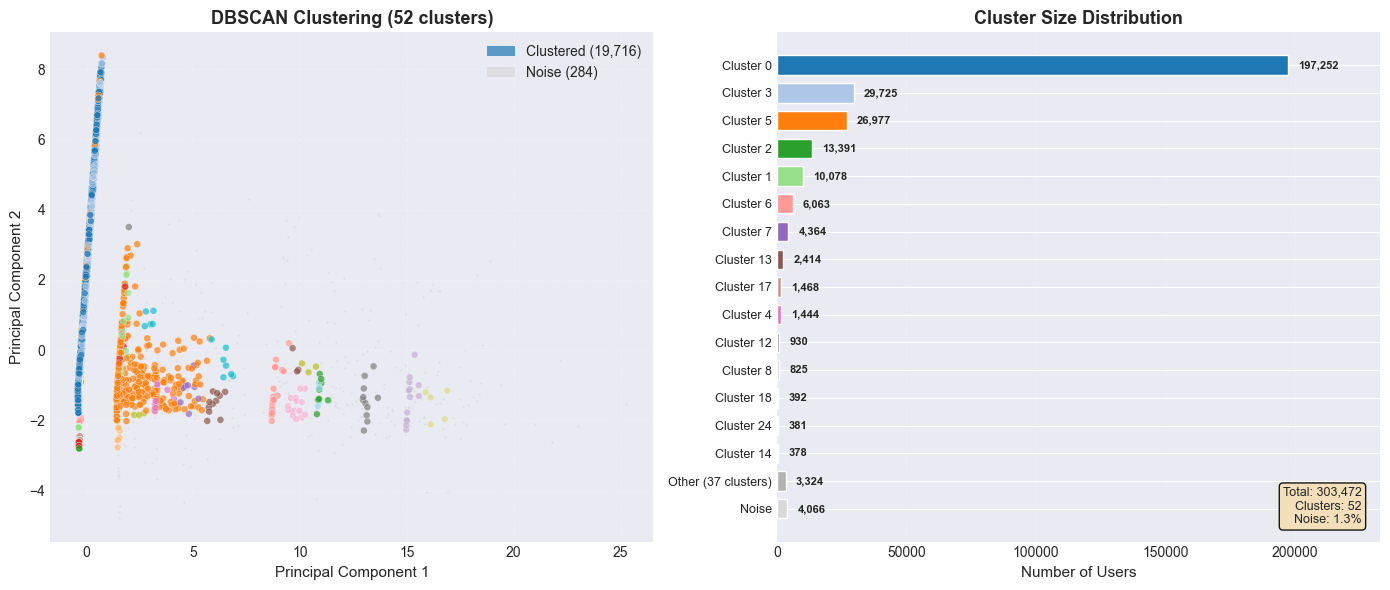

Figure 5 saved


In [19]:
# Figure 5: PCA clusters (improved visualization)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sample for plotting if too many points
PLOT_SAMPLE = 20000
if len(X_pca) > PLOT_SAMPLE:
    plot_idx = np.random.choice(len(X_pca), PLOT_SAMPLE, replace=False)
    X_plot = X_pca[plot_idx]
    labels_plot = dbscan_labels[plot_idx]
else:
    X_plot = X_pca
    labels_plot = dbscan_labels

unique_labels = sorted(set(dbscan_labels))
n_clusters = len([l for l in unique_labels if l != -1])

# === Left plot: Scatter with color gradient ===
ax1 = axes[0]

# Plot noise first (background)
noise_mask = labels_plot == -1
if noise_mask.sum() > 0:
    ax1.scatter(X_plot[noise_mask, 0], X_plot[noise_mask, 1], 
                c='lightgray', marker='.', alpha=0.3, s=3, zorder=1)

# Plot all clusters with continuous colormap (no legend per cluster)
cluster_mask = labels_plot != -1
if cluster_mask.sum() > 0:
    scatter = ax1.scatter(X_plot[cluster_mask, 0], X_plot[cluster_mask, 1], 
                          c=labels_plot[cluster_mask], cmap='tab20', 
                          marker='o', alpha=0.7, s=25, 
                          edgecolors='white', linewidths=0.3, zorder=2)

ax1.set_xlabel('Principal Component 1', fontsize=11)
ax1.set_ylabel('Principal Component 2', fontsize=11)
ax1.set_title(f'DBSCAN Clustering ({n_clusters} clusters)', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.2, linestyle='--')

# Simple legend for noise vs clusters
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tab:blue', alpha=0.7, label=f'Clustered ({cluster_mask.sum():,})'),
    Patch(facecolor='lightgray', alpha=0.5, label=f'Noise ({noise_mask.sum():,})')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=10)

# === Right plot: Top 15 clusters + Others + Noise ===
ax2 = axes[1]

# Get cluster sizes from full data
cluster_sizes = {}
for label in unique_labels:
    cluster_sizes[label] = (dbscan_labels == label).sum()

# Separate noise
noise_count = cluster_sizes.pop(-1, 0)

# Sort clusters by size
sorted_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)

# Top 15 + aggregate others
TOP_N = 15
if len(sorted_clusters) > TOP_N:
    top_clusters = sorted_clusters[:TOP_N]
    others_count = sum(c[1] for c in sorted_clusters[TOP_N:])
    others_n = len(sorted_clusters) - TOP_N
else:
    top_clusters = sorted_clusters
    others_count = 0
    others_n = 0

# Build plot data
plot_labels = [f'Cluster {c[0]}' for c in top_clusters]
plot_counts = [c[1] for c in top_clusters]
plot_colors = plt.cm.tab20(np.linspace(0, 1, len(top_clusters)))

if others_count > 0:
    plot_labels.append(f'Other ({others_n} clusters)')
    plot_counts.append(others_count)
    plot_colors = np.vstack([plot_colors, [0.7, 0.7, 0.7, 1.0]])

plot_labels.append('Noise')
plot_counts.append(noise_count)
plot_colors = np.vstack([plot_colors, [0.85, 0.85, 0.85, 1.0]])

# Horizontal bar chart
y_pos = range(len(plot_counts))
bars = ax2.barh(y_pos, plot_counts, color=plot_colors, edgecolor='white', height=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(plot_labels, fontsize=9)
ax2.set_xlabel('Number of Users', fontsize=11)
ax2.set_title('Cluster Size Distribution', fontsize=13, fontweight='bold')
ax2.invert_yaxis()

# Add count labels
max_count = max(plot_counts)
for bar, count in zip(bars, plot_counts):
    ax2.text(count + max_count * 0.02, bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', fontsize=8, fontweight='bold')

ax2.set_xlim(0, max_count * 1.18)
ax2.grid(axis='x', alpha=0.2, linestyle='--')

# Summary stats
total = len(dbscan_labels)
noise_pct = noise_count / total * 100
stats_text = f'Total: {total:,}\nClusters: {n_clusters}\nNoise: {noise_pct:.1f}%'
ax2.text(0.97, 0.03, stats_text, transform=ax2.transAxes, fontsize=9,
         va='bottom', ha='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

plt.tight_layout()
plt.savefig(output_dir / 'fig5_pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 5 saved")

---
# PHASE 5: Anomaly Detection
---

## 5.1 Extract DBSCAN Noise

In [20]:
print("Extracting DBSCAN noise for anomaly detection...\n")

noise_mask = dbscan_labels == -1
X_noise = X_pca[noise_mask]
noise_user_ids = user_ids[noise_mask]

print(f"Noise points: {len(X_noise):,}")
print(f"Percentage: {len(X_noise)/len(X_pca)*100:.1f}%")

# Clean normal users for training
features_dict = {row['user_id']: row for row in features_df.iter_rows(named=True)}

clean_mask = np.array([
    features_dict[uid]['lsh_hits'] == 0 and features_dict[uid]['itemset_memberships'] == 0
    for uid in noise_user_ids
])

X_clean = X_noise[clean_mask]
print(f"Clean normal users: {len(X_clean):,}")

Extracting DBSCAN noise for anomaly detection...

Noise points: 4,066
Percentage: 1.3%
Clean normal users: 2,987


## 5.2 Train One-Class SVM

In [21]:
print("Training One-Class SVM...\n")

NU = 0.05
ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=NU)
ocsvm.fit(X_clean)

print(f"Trained on {len(X_clean):,} clean users")
print(f"Nu (contamination): {NU}")

Training One-Class SVM...

Trained on 2,987 clean users
Nu (contamination): 0.05


## 5.3 Predict Anomalies

In [22]:
print("Predicting anomalies...\n")

noise_predictions = ocsvm.predict(X_noise)
noise_scores = ocsvm.decision_function(X_noise)

anomalies_mask = noise_predictions == -1
num_anomalies = anomalies_mask.sum()

print(f"Anomalies detected: {num_anomalies:,}")
print(f"Percentage of noise: {num_anomalies/len(X_noise)*100:.1f}%")
print(f"Percentage of all users: {num_anomalies/len(X_pca)*100:.2f}%")

anomalous_user_ids = noise_user_ids[anomalies_mask]

Predicting anomalies...



Anomalies detected: 1,153
Percentage of noise: 28.4%
Percentage of all users: 0.38%


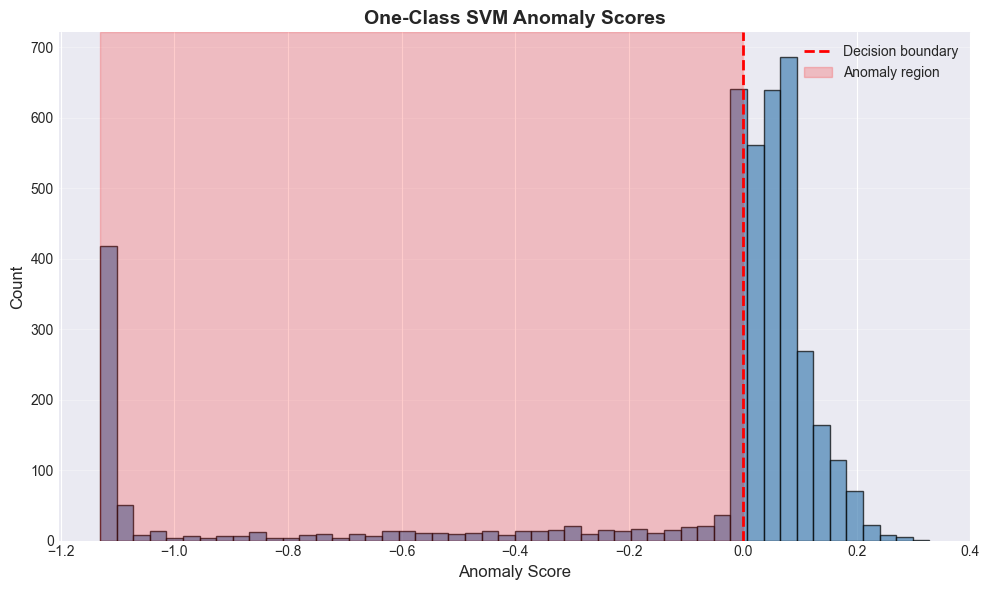

Figure 7 saved


In [23]:
# Figure 7: Anomaly scores
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(noise_scores, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Decision boundary')
ax.axvspan(noise_scores.min(), 0, alpha=0.2, color='red', label='Anomaly region')

ax.set_xlabel('Anomaly Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('One-Class SVM Anomaly Scores', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'fig7_anomaly_scores.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 7 saved")

---
# Campaign Risk Score
---

In [24]:
print("Calculating Campaign Risk Scores...\n")

W_LSH = 0.3
W_ITEMSET = 0.3
W_ANOMALY = 0.2
W_VERIFIED = 0.2

risk_scores = {}

for uid in user_ids:
    feat = features_dict[uid]
    
    lsh_score = min(feat['lsh_hits'] / 5, 1.0)
    itemset_score = min(feat['itemset_memberships'] / 3, 1.0)
    
    if uid in anomalous_user_ids:
        anomaly_score = 1.0
    elif uid in noise_user_ids:
        anomaly_score = 0.0
    else:
        anomaly_score = 0.5
    
    # Low verified ratio is suspicious
    verified_score = 1.0 - feat['verified_ratio']
    
    risk = (W_LSH * lsh_score + W_ITEMSET * itemset_score + 
            W_ANOMALY * anomaly_score + W_VERIFIED * verified_score)
    
    risk_scores[uid] = {
        'lsh_score': lsh_score,
        'itemset_score': itemset_score,
        'anomaly_score': anomaly_score,
        'verified_score': verified_score,
        'campaign_risk': risk
    }

risk_df = pl.DataFrame([{'user_id': uid, **s} for uid, s in risk_scores.items()]).sort('campaign_risk', descending=True)

print(f"Risk scores calculated for {len(risk_scores):,} users")
print(f"\nTop 10 highest-risk users:")
print(risk_df.head(10))

Calculating Campaign Risk Scores...

Risk scores calculated for 303,472 users

Top 10 highest-risk users:
shape: (10, 6)
┌─────────────────────┬───────────┬───────────────┬───────────────┬────────────────┬───────────────┐
│ user_id             ┆ lsh_score ┆ itemset_score ┆ anomaly_score ┆ verified_score ┆ campaign_risk │
│ ---                 ┆ ---       ┆ ---           ┆ ---           ┆ ---            ┆ ---           │
│ str                 ┆ f64       ┆ f64           ┆ f64           ┆ f64            ┆ f64           │
╞═════════════════════╪═══════════╪═══════════════╪═══════════════╪════════════════╪═══════════════╡
│ AGYNCDY6GN44NPF6RWR ┆ 1.0       ┆ 1.0           ┆ 1.0           ┆ 0.0            ┆ 0.8           │
│ HBQ23E72A           ┆           ┆               ┆               ┆                ┆               │
│ AFOQ6KZDCYQ7NG3IP6V ┆ 1.0       ┆ 1.0           ┆ 1.0           ┆ 0.0            ┆ 0.8           │
│ I6MQQEB7Q           ┆           ┆               ┆               ┆    

## Summary Statistics

In [26]:
print("="*70)
print("PIPELINE SUMMARY")
print("="*70)

print(f"\n[Dataset]")
print(f"Total reviews: {len(reviews_df):,}")
if ground_truth_labels is not None:
    print(f"Fake reviews: {(ground_truth_labels == 1).sum():,} ({(ground_truth_labels == 1).mean()*100:.1f}%)")
    print(f"Real reviews: {(ground_truth_labels == 0).sum():,} ({(ground_truth_labels == 0).mean()*100:.1f}%)")

print(f"\n[Phase 1: LSH]")
print(f"Near-duplicate pairs: {len(near_duplicate_pairs):,}")
print(f"LSH speedup: {speedup:.1f}x")

print(f"\n[Phase 2: FP-Growth]")
print(f"Frequent itemsets: {len(frequent_itemsets):,}")
print(f"Reviewer rings (2+): {len(reviewer_rings):,}")

print(f"\n[Phase 3: Features]")
print(f"Original dimensions: {len(feature_cols)}")
print(f"PCA dimensions: {pca.n_components_}")

print(f"\n[Phase 4: Clustering]")
print(f"DBSCAN silhouette: {dbscan_silhouette:.3f}")
print(f"DBSCAN clusters: {num_clusters}")
print(f"DBSCAN noise: {num_noise:,}")

print(f"\n[Phase 5: Anomaly Detection]")
print(f"Training set size: {len(X_clean):,}")
print(f"Anomalies detected: {num_anomalies:,}")

high_risk = (risk_df['campaign_risk'] > 0.6).sum()
medium_risk = ((risk_df['campaign_risk'] > 0.3) & (risk_df['campaign_risk'] <= 0.6)).sum()
print(f"\n[Risk Summary]")
print(f"High-risk users (>0.6): {high_risk:,}")
print(f"Medium-risk users (0.3-0.6): {medium_risk:,}")

print("\n" + "="*70)

PIPELINE SUMMARY

[Dataset]
Total reviews: 2,128,605

[Phase 1: LSH]
Near-duplicate pairs: 3,819,581
LSH speedup: 0.3x

[Phase 2: FP-Growth]
Frequent itemsets: 626
Reviewer rings (2+): 10

[Phase 3: Features]
Original dimensions: 11
PCA dimensions: 8

[Phase 4: Clustering]
DBSCAN silhouette: 0.265
DBSCAN clusters: 52
DBSCAN noise: 4,066

[Phase 5: Anomaly Detection]
Training set size: 2,987
Anomalies detected: 1,153

[Risk Summary]
High-risk users (>0.6): 400
Medium-risk users (0.3-0.6): 36,922



## Save Results

In [ ]:
print("Saving results...\n")

risk_df.write_csv('campaign_risk_scores.csv')
print("Saved campaign_risk_scores.csv")

if len(near_duplicate_pairs) > 0:
    pl.DataFrame(near_duplicate_pairs).write_csv('near_duplicate_pairs.csv')
    print("Saved near_duplicate_pairs.csv")

cluster_df = pl.DataFrame({
    'user_id': user_ids,
    'cluster': dbscan_labels,
    'is_noise': dbscan_labels == -1,
    'is_anomaly': np.isin(user_ids, anomalous_user_ids)
})
cluster_df.write_csv('cluster_assignments.csv')
print("Saved cluster_assignments.csv")

print("\nAll results saved!")

Saving results...

Saved campaign_risk_scores.csv
Saved near_duplicate_pairs.csv
Saved cluster_assignments.csv

All results saved!


---
# Pipeline Complete!
---

## Generated Outputs

**Figures** (in `output/`):
- `fig4_pca_variance.png`: PCA explained variance
- `fig5_pca_clusters.png`: DBSCAN clusters
- `fig6_clustering_comparison.png`: Method comparison
- `fig7_anomaly_scores.png`: Anomaly score distribution
- `fig8_itemsets.png`: Frequent itemsets

**Data Files**:
- `campaign_risk_scores.csv`: Risk scores for all users
- `near_duplicate_pairs.csv`: LSH-detected duplicates
- `cluster_assignments.csv`: Cluster labels